## Import

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, precision_recall_curve, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

### 1. Data Load

In [7]:
df_raw = pd.read_csv("features_wide.csv")
print(df_raw.shape)

(267280, 25)


In [8]:
print(df_raw.head())
print(df_raw.info())

      cik     sic   year_q        Assets  AssetsCurrent  \
0  1750.0  3720.0  2010-Q3  1.501042e+09    863429000.0   
1  1750.0  3720.0  2010-Q4  1.501042e+09    863429000.0   
2  1750.0  3720.0  2011-Q1  1.501042e+09    863429000.0   
3  1750.0  3720.0  2011-Q2  1.500181e+09    846331000.0   
4  1750.0  3720.0  2011-Q3  1.703727e+09    913985000.0   

   CashAndCashEquivalentsAtCarryingValue  GeneralAndAdministrativeExpense  \
0                            112505000.0                              0.0   
1                            112505000.0                              0.0   
2                            112505000.0                              0.0   
3                            109391000.0                              0.0   
4                             79370000.0                              0.0   

   Goodwill  GrossProfit  \
0       0.0          0.0   
1       0.0          0.0   
2       0.0          0.0   
3       0.0          0.0   
4       0.0   70001000.0   

   IncomeLoss

Tên các cột:
['cik', 'sic', 'year_q', 'Assets', 'AssetsCurrent', 'CashAndCashEquivalentsAtCarryingValue', 'GeneralAndAdministrativeExpense', 'Goodwill', 'GrossProfit', 'IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest', 'IncomeTaxExpenseBenefit', 'InterestExpense', 'Liabilities', 'LiabilitiesCurrent', 'NetIncomeLoss', 'NonoperatingIncomeExpense', 'OperatingExpenses', 'OperatingIncomeLoss', 'OtherNonoperatingIncomeExpense', 'Revenues', 'SellingGeneralAndAdministrativeExpense', 'ShareBasedCompensation', 'StockholdersEquity', 'WeightedAverageNumberOfDilutedSharesOutstanding', 'WeightedAverageNumberOfSharesOutstandingBasic']

Thống kê mô tả:


                cik            sic        Assets  AssetsCurrent  \
count  2.672800e+05  267280.000000  2.672800e+05   2.672800e+05   
mean   1.132606e+06    4839.810663  1.203272e+10   1.266662e+09   
std    5.128089e+05    2028.283500  1.076691e+11   6.410654e+09   
min    1.750000e+03       0.000000 -1.300000e+01  -1.738730e+05   
25%    8.667290e+05    2891.000000  2.850175e+07   3.094100e+04   
50%    1.174922e+06    4911.000000  4.636710e+08   3.368580e+07   
75%    1.530950e+06    6770.000000  3.115179e+09   4.495632e+08   
max    1.941536e+06    9995.000000  4.909004e+12   2.035858e+11   

       CashAndCashEquivalentsAtCarryingValue  GeneralAndAdministrativeExpense  \
count                           2.672800e+05                     2.672800e+05   
mean                            4.425104e+08                     1.090936e+08   
std                             4.539952e+09                     4.141726e+10   
min                            -1.850190e+08                    -1.40919

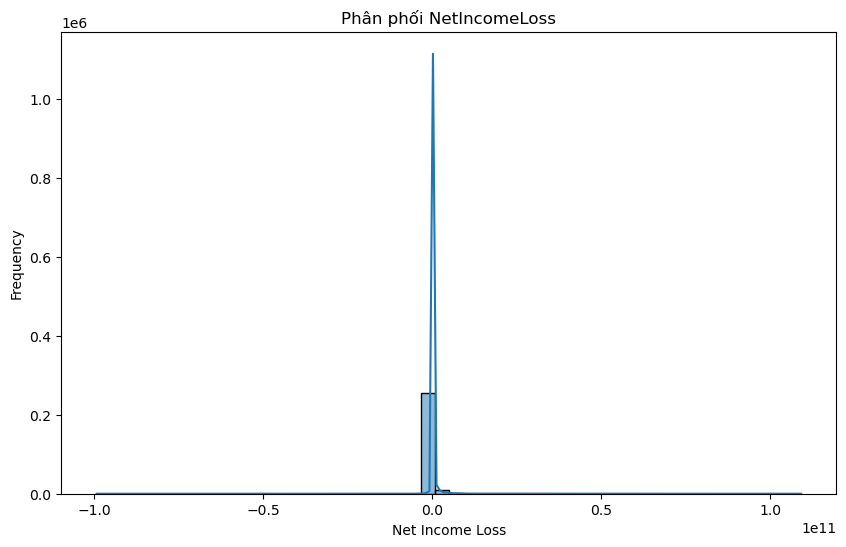

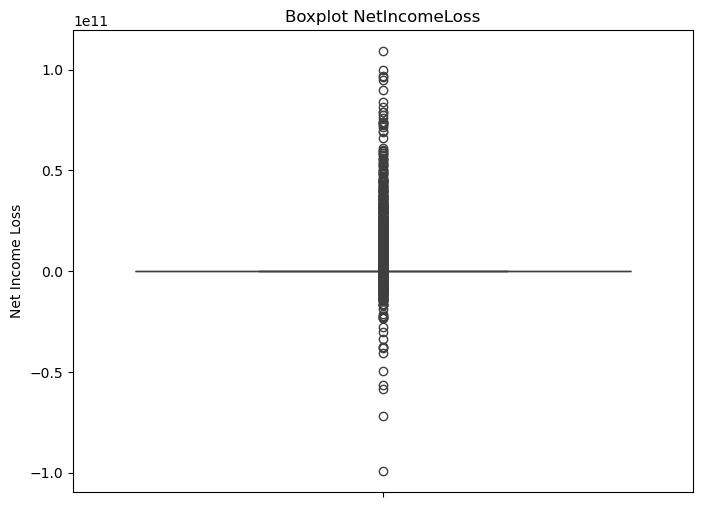


Phân phối Revenues:


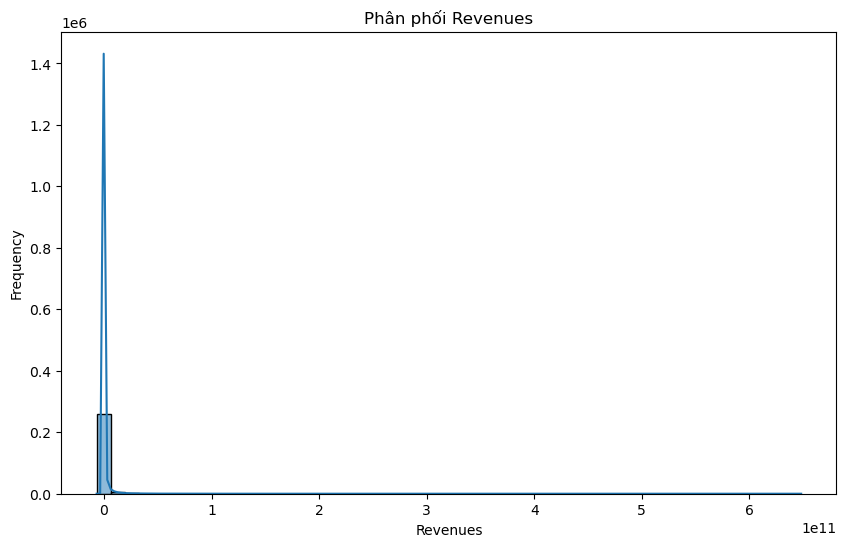

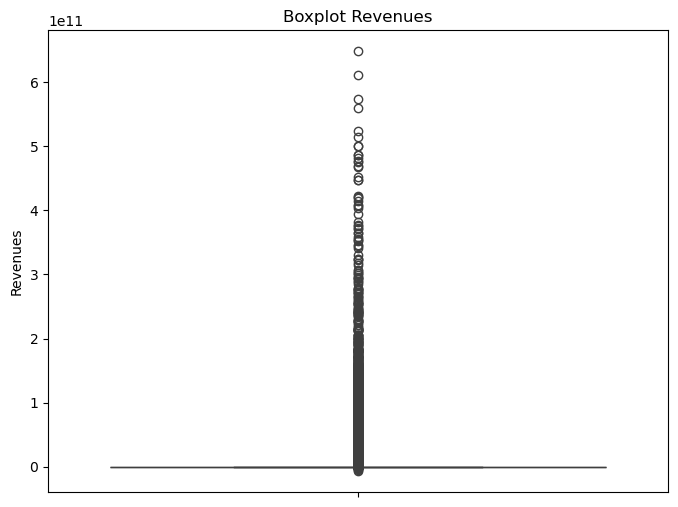

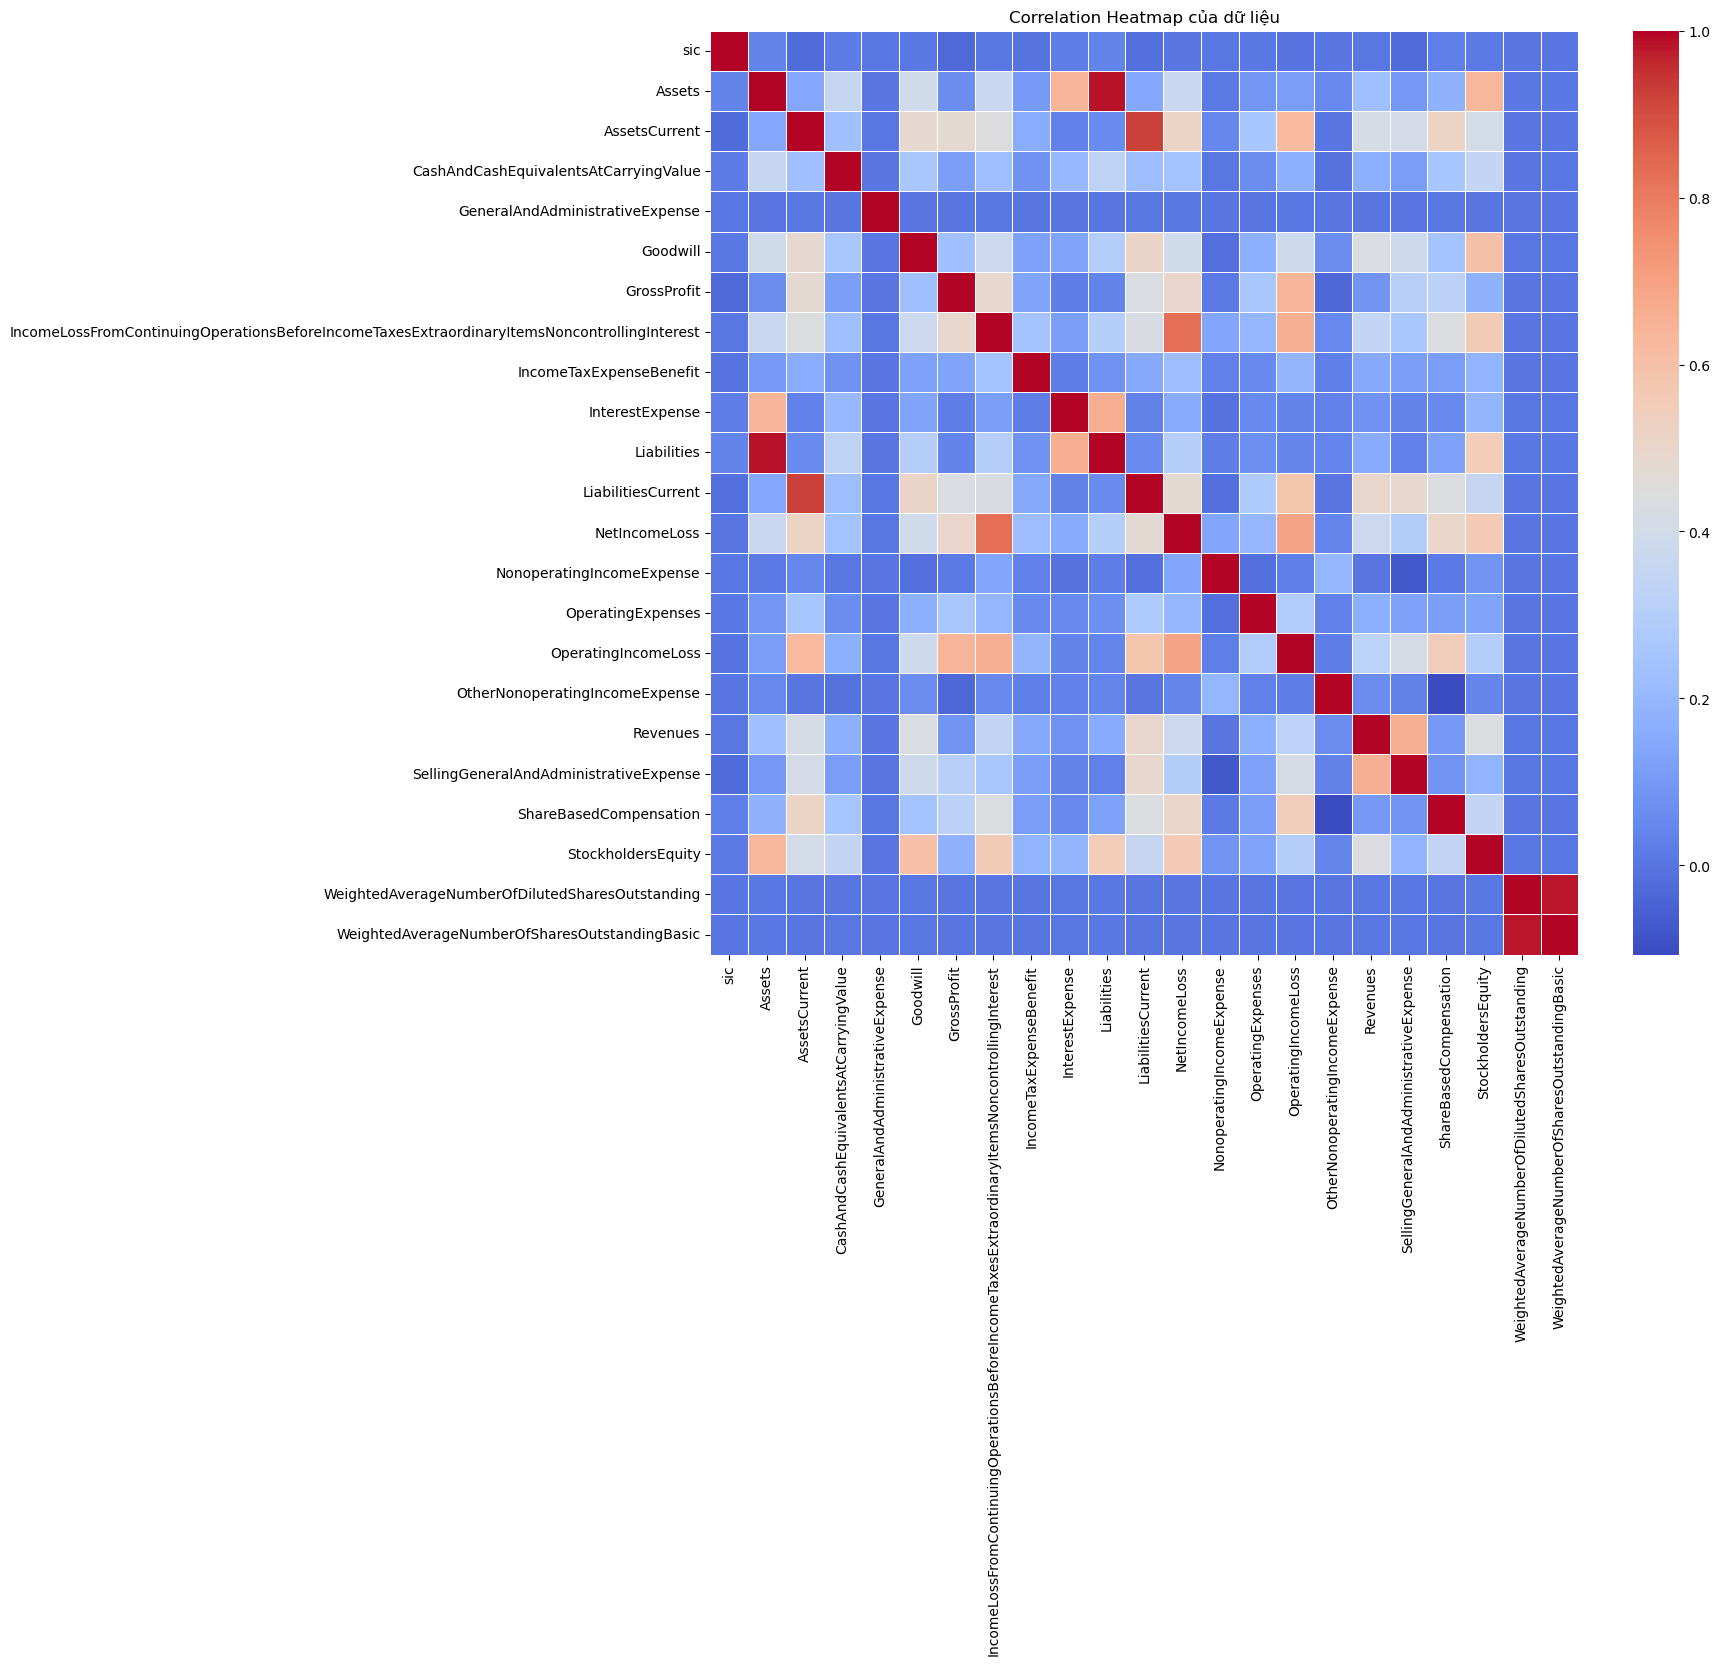

In [9]:
print("Tên các cột:")
print(df_raw.columns.tolist())

# Thống kê mô tả
print("\nThống kê mô tả:")
print(df_raw.describe())

# Phân tích dữ liệu trước khi làm sạch
print("\nPhân phối NetIncomeLoss:")
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['NetIncomeLoss'].dropna(), kde=True, bins=50)
plt.title('Phân phối NetIncomeLoss')
plt.xlabel('Net Income Loss')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_raw['NetIncomeLoss'].dropna())
plt.title('Boxplot NetIncomeLoss')
plt.ylabel('Net Income Loss')
plt.show()

print("\nPhân phối Revenues:")
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['Revenues'].dropna(), kde=True, bins=50)
plt.title('Phân phối Revenues')
plt.xlabel('Revenues')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_raw['Revenues'].dropna())
plt.title('Boxplot Revenues')
plt.ylabel('Revenues')
plt.show()

# Correlation heatmap
raw_numeric = df_raw.select_dtypes(include=[np.number]).copy()
if 'cik' in raw_numeric.columns:
    raw_numeric = raw_numeric.drop(columns=['cik'])
raw_corr = raw_numeric.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(raw_corr, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap của dữ liệu')
plt.show()

## Data Preparation

In [10]:
# Kiểm tra giá trị thiếu
print("Giá trị thiếu theo cột:")
print(df_raw.isnull().sum())

# Xử lý giá trị thiếu
df = df_raw.copy()
df = df.dropna()

if 'year_q' in df.columns:
    df['date'] = pd.to_datetime(df['year_q'].str.replace('Q1', '-01-01').str.replace('Q2', '-04-01').str.replace('Q3', '-07-01').str.replace('Q4', '-10-01'))
else:
    print("Cảnh báo: Không tìm thấy cột 'year_q'.")

if 'cik' in df.columns and 'date' in df.columns:
    df = df.sort_values(['cik', 'date'])
else:
    print("Cảnh báo: Không tìm thấy cột 'cik' hoặc 'date'.")


Giá trị thiếu theo cột:
cik                                                                                            0
sic                                                                                            0
year_q                                                                                         0
Assets                                                                                         0
AssetsCurrent                                                                                  0
CashAndCashEquivalentsAtCarryingValue                                                          0
GeneralAndAdministrativeExpense                                                                0
Goodwill                                                                                       0
GrossProfit                                                                                    0
IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest    0
Income

## Feature Engineering

Kích thước dữ liệu sau feature engineering: (64026, 37)
        cik     sic   year_q       Assets  AssetsCurrent  \
212  2098.0  3420.0  2018-Q1  114730000.0     77818000.0   
213  2098.0  3420.0  2018-Q2  114730000.0     77818000.0   
214  2098.0  3420.0  2018-Q3  114730000.0     77818000.0   
215  2098.0  3420.0  2018-Q4  114729806.0     77817645.0   
216  2098.0  3420.0  2019-Q1  109478000.0     72992000.0   

     CashAndCashEquivalentsAtCarryingValue  GeneralAndAdministrativeExpense  \
212                              5911000.0                              0.0   
213                              5911000.0                              0.0   
214                              5911000.0                              0.0   
215                              5910770.0                              0.0   
216                              9338000.0                              0.0   

      Goodwill  GrossProfit  \
212  4696000.0   10564000.0   
213  4696000.0   25047000.0   
214  4696000.0 

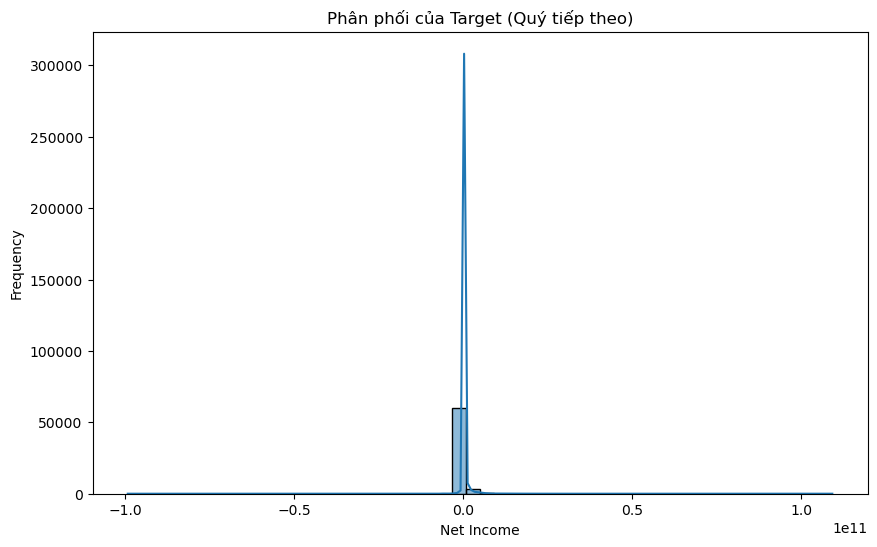

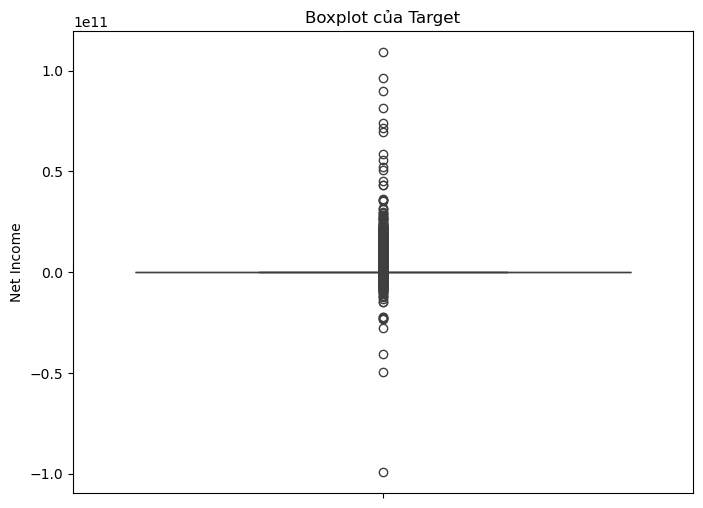

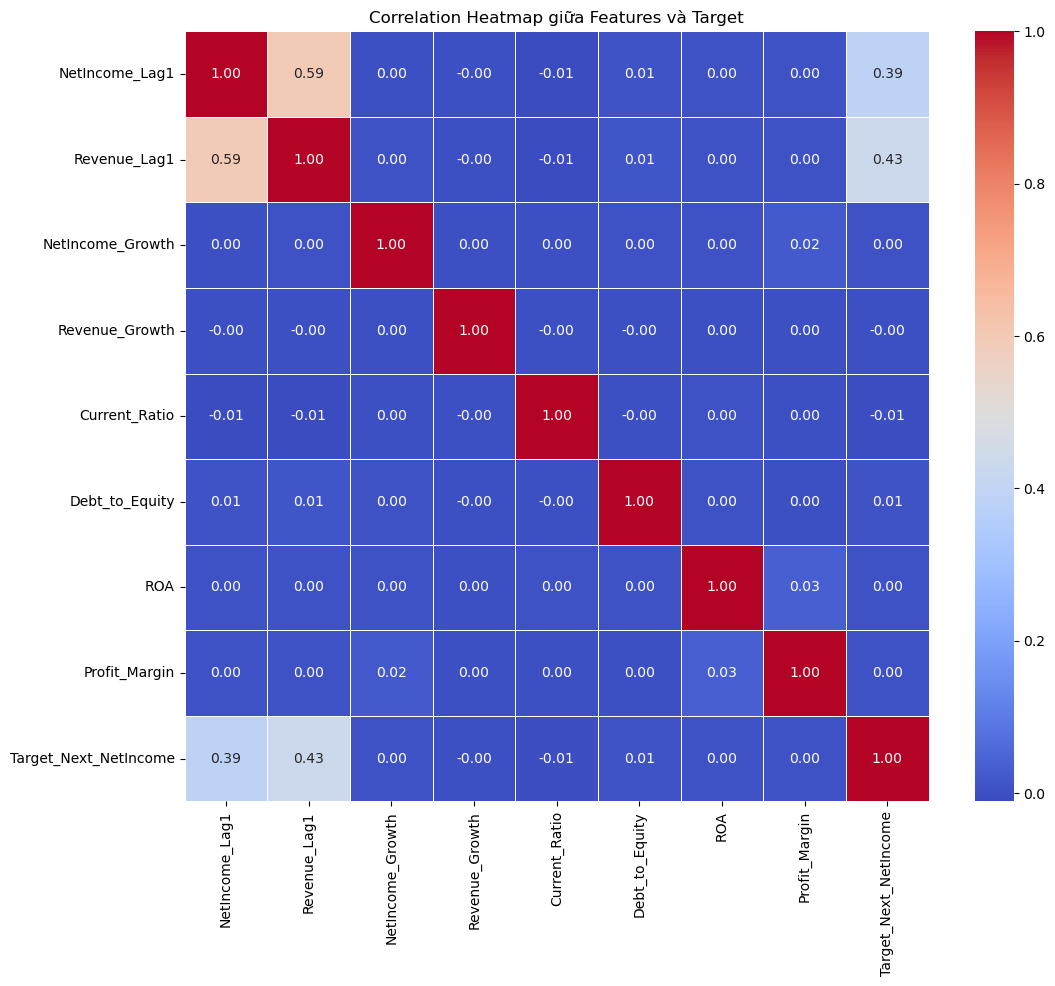

Phân tích Outliers trong Target:
Số outliers trong target: 13641 / 64026 (21.3%)
Range target: -99289000000.00 to 109118000000.00
IQR bounds: -86131036.88 to 133612622.12


In [11]:
# Tạo features
df['NetIncome_Lag1'] = df.groupby('cik')['NetIncomeLoss'].shift(1)
df['Revenue_Lag1'] = df.groupby('cik')['Revenues'].shift(1)

# Tỷ lệ tăng trưởng
df['NetIncome_Growth'] = (df['NetIncomeLoss'] - df['NetIncome_Lag1']) / df['NetIncome_Lag1'].replace(0, np.nan).abs()
df['Revenue_Growth'] = (df['Revenues'] - df['Revenue_Lag1']) / df['Revenue_Lag1'].replace(0, np.nan).abs()

df['Current_Ratio'] = df['Assets'] / df['Liabilities'].replace(0, np.nan)
df['Debt_to_Equity'] = df['Liabilities'] / (df['Assets'] - df['Liabilities']).replace(0, np.nan)
df['ROA'] = df['NetIncomeLoss'] / df['Assets'].replace(0, np.nan)
df['Profit_Margin'] = df['NetIncomeLoss'] / df['Revenues'].replace(0, np.nan)

# Dự đoán Net Income quý tiếp theo
df['Target_Next_NetIncome'] = df.groupby('cik')['NetIncomeLoss'].shift(-1)

# Tạo label phân loại dựa trên sự thay đổi từ quý hiện tại đến quý tiếp theo
df['Change'] = df['Target_Next_NetIncome'] - df['NetIncomeLoss']
df['Label'] = pd.cut(df['Change'], bins=[-np.inf, -0.01, 0.01, np.inf], labels=['Decrease', 'Stable', 'Increase'])

df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("Kích thước dữ liệu sau feature engineering:", df.shape)
print(df.head())

# Phân phối Target
plt.figure(figsize=(10, 6))
sns.histplot(df['Target_Next_NetIncome'], kde=True, bins=50)
plt.title('Phân phối của Target (Quý tiếp theo)')
plt.xlabel('Net Income')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Target_Next_NetIncome'])
plt.title('Boxplot của Target')
plt.ylabel('Net Income')
plt.show()

# Correlation Heatmap
features_for_corr = ['NetIncome_Lag1', 'Revenue_Lag1', 'NetIncome_Growth', 'Revenue_Growth', 'Current_Ratio', 'Debt_to_Equity', 'ROA', 'Profit_Margin', 'Target_Next_NetIncome']
corr = df[features_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap giữa Features và Target')
plt.show()

# Phân tích Outliers
print("Phân tích Outliers trong Target:")
Q1 = df['Target_Next_NetIncome'].quantile(0.25)
Q3 = df['Target_Next_NetIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Target_Next_NetIncome'] < lower_bound) | (df['Target_Next_NetIncome'] > upper_bound)]
print(f"Số outliers trong target: {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Range target: {df['Target_Next_NetIncome'].min():.2f} to {df['Target_Next_NetIncome'].max():.2f}")
print(f"IQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")

## Train-Test Split (Time Series)

In [12]:
df = df.sort_values('date')

# Features
features = ['NetIncome_Lag1', 'Revenue_Lag1', 'NetIncome_Growth', 'Revenue_Growth', 'Current_Ratio', 'Debt_to_Equity', 'ROA', 'Profit_Margin']
X = df[features]
y = df['Target_Next_NetIncome']

# Train trên dữ liệu cũ, test trên dữ liệu mới
split_point = int(0.8 * len(df))
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print("Kích thước train:", X_train.shape, y_train.shape)
print("Kích thước test:", X_test.shape, y_test.shape)

Kích thước train: (51220, 8) (51220,)
Kích thước test: (12806, 8) (12806,)


## Data Cleaning

In [13]:
# Loại bỏ outliers trong target (IQR method) - chỉ trên train set
print("Xử lý Outliers trên train set")
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc dữ liệu train không có outliers
mask_no_outliers_train = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train_clean = X_train[mask_no_outliers_train]
y_train_clean = y_train[mask_no_outliers_train]

print(f"Train dữ liệu gốc: {len(X_train)} samples")
print(f"Train sau loại bỏ outliers: {len(X_train_clean)} samples (loại bỏ {len(X_train) - len(X_train_clean)} samples)")
print(f"Tỷ lệ loại bỏ: {((len(X_train) - len(X_train_clean)) / len(X_train) * 100):.1f}%")

# Normalize features
scaler = StandardScaler()
X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled = scaler.transform(X_test)

# Dùng target train/test
y_train_clean_original = y_train_clean
y_test_clean_original = y_test

print("\nNormalization")
print(f"Train features scaled - Mean: {X_train_clean_scaled.mean():.4f}, Std: {X_train_clean_scaled.std():.4f}")
print(f"Train target range: {y_train_clean_original.min():.2f} to {y_train_clean_original.max():.2f}")
print(f"Test target range: {y_test_clean_original.min():.2f} to {y_test_clean_original.max():.2f}")

print(f"\nTrain set: {X_train_clean_scaled.shape[0]} samples")
print(f"Test set: {X_test_clean_scaled.shape[0]} samples")

Xử lý Outliers trên train set
Train dữ liệu gốc: 51220 samples
Train sau loại bỏ outliers: 40429 samples (loại bỏ 10791 samples)
Tỷ lệ loại bỏ: 21.1%

Normalization
Train features scaled - Mean: -0.0000, Std: 1.0000
Train target range: -78239000.00 to 121971000.00
Test target range: -40839000000.00 to 96223000000.00

Train set: 40429 samples
Test set: 12806 samples


## Modeling

In [14]:
# Huấn luyện mô hình RandomForest Regression
model = RandomForestRegressor(n_estimators=150, max_depth=25, min_samples_split=5, random_state=42)
model.fit(X_train_clean_scaled, y_train_clean)

y_pred = model.predict(X_test_clean_scaled)

mae = mean_absolute_error(y_test_clean_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_clean_original, y_pred))
r2 = 1 - (np.sum((y_test_clean_original - y_pred)**2) / np.sum((y_test_clean_original - y_test_clean_original.mean())**2))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# RMSLE
rmsle = np.sqrt(np.mean((np.log1p(np.abs(y_test_clean_original)) - np.log1p(np.abs(y_pred)))**2))
print(f"RMSLE: {rmsle:.4f}")

# MAPE
mask_meaningful = np.abs(y_test_clean_original) > 1e6
mape = np.mean(np.abs((y_test_clean_original[mask_meaningful] - y_pred[mask_meaningful]) / y_test_clean_original[mask_meaningful])) * 100 if mask_meaningful.sum() > 0 else np.nan
print(f"MAPE (meaningful values): {mape:.2f}%")

# Nhận xét về kết quả
print("\n--- Nhận xét về kết quả Regression ---")
print(f"- MAE {mae:.2f}: Sai số tuyệt đối trung bình, khá cao so với range target ({y_test_clean_original.min():.2f} to {y_test_clean_original.max():.2f}).")
print(f"- RMSE {rmse:.2f}: Lớn hơn MAE, cho thấy có outliers trong sai số.")
print(f"- R² {r2:.4f}: Thấp, model chỉ giải thích được {r2*100:.1f}% variance, kém.")
print(f"- RMSLE {rmsle:.4f}: Tương đối thấp, nhưng không bù đắp cho metrics khác.")
print(f"- MAPE {mape:.2f}%: Rất cao (>100%), model dự đoán kém, sai số trung bình bằng {mape:.1f}% giá trị thực.")
print("- Nguyên nhân: Data phức tạp (financial time series), features có thể thiếu, model RandomForest có thể overfitting hoặc underfitting.")
print("- Cải thiện: Thêm features (macro indicators), tune hyperparameters, thử models khác (LSTM, Gradient Boosting), hoặc ensemble.")

MAE: 412325481.66
RMSE: 2550725170.76
R² Score: -0.0155
RMSLE: 2.6038
MAPE (meaningful values): 91.19%

--- Nhận xét về kết quả Regression ---
- MAE 412325481.66: Sai số tuyệt đối trung bình, khá cao so với range target (-40839000000.00 to 96223000000.00).
- RMSE 2550725170.76: Lớn hơn MAE, cho thấy có outliers trong sai số.
- R² -0.0155: Thấp, model chỉ giải thích được -1.5% variance, kém.
- RMSLE 2.6038: Tương đối thấp, nhưng không bù đắp cho metrics khác.
- MAPE 91.19%: Rất cao (>100%), model dự đoán kém, sai số trung bình bằng 91.2% giá trị thực.
- Nguyên nhân: Data phức tạp (financial time series), features có thể thiếu, model RandomForest có thể overfitting hoặc underfitting.
- Cải thiện: Thêm features (macro indicators), tune hyperparameters, thử models khác (LSTM, Gradient Boosting), hoặc ensemble.


### Time Series Forecasting

In [15]:
# Cross-Validation cho Time Series sử dụng TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []

for train_index, val_index in tscv.split(X_train_clean_scaled):
    X_train_fold, X_val_fold = X_train_clean_scaled[train_index], X_train_clean_scaled[val_index]
    y_train_fold, y_val_fold = y_train_clean.iloc[train_index], y_train_clean.iloc[val_index]
    
    ts_model = RandomForestRegressor(n_estimators=150, max_depth=25, min_samples_split=5, random_state=42)
    ts_model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = ts_model.predict(X_val_fold)
    
    mae_scores.append(mean_absolute_error(y_val_fold, y_pred_fold))
    rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_fold)))

print(f"Time Series CV - MAE: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"Time Series CV - RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")

# Mô hình cuối cùng được huấn luyện trên toàn bộ tập train, dự đoán trên test
ts_model.fit(X_train_clean_scaled, y_train_clean)
y_pred_ts = ts_model.predict(X_test_clean_scaled)

mae_ts = mean_absolute_error(y_test_clean_original, y_pred_ts)
rmse_ts = np.sqrt(mean_squared_error(y_test_clean_original, y_pred_ts))
print(f"Final Test - MAE: {mae_ts:.2f}, RMSE: {rmse_ts:.2f}")

Time Series CV - MAE: 9963397.92 ± 695438.35
Time Series CV - RMSE: 19175776.77 ± 972495.38
Final Test - MAE: 412325481.66, RMSE: 2550725170.76


### Classification: Predict Growth Categories from Next Quarter Net Income

In [16]:
# Classification dựa trên Label từ Target_Next_NetIncome
y_train_class = df['Label'][:split_point][mask_no_outliers_train]
y_test_class = df['Label'][split_point:]

X_train_class_clean = X_train_clean_scaled
X_test_class_clean = X_test_clean_scaled

# RandomForest Classifier
class_model = RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_split=5, random_state=42)
class_model.fit(X_train_class_clean, y_train_class)

y_pred_class = class_model.predict(X_test_class_clean)

f1 = f1_score(y_test_class, y_pred_class, average='weighted')
print(f"Classification - F1 Score: {f1:.4f}")
print(classification_report(y_test_class, y_pred_class))

Classification - F1 Score: 0.5893
              precision    recall  f1-score   support

    Decrease       0.53      0.70      0.60      5094
    Increase       0.64      0.56      0.59      5557
      Stable       0.78      0.43      0.55      2155

    accuracy                           0.59     12806
   macro avg       0.65      0.56      0.58     12806
weighted avg       0.62      0.59      0.59     12806



## Insights (Feature importance)

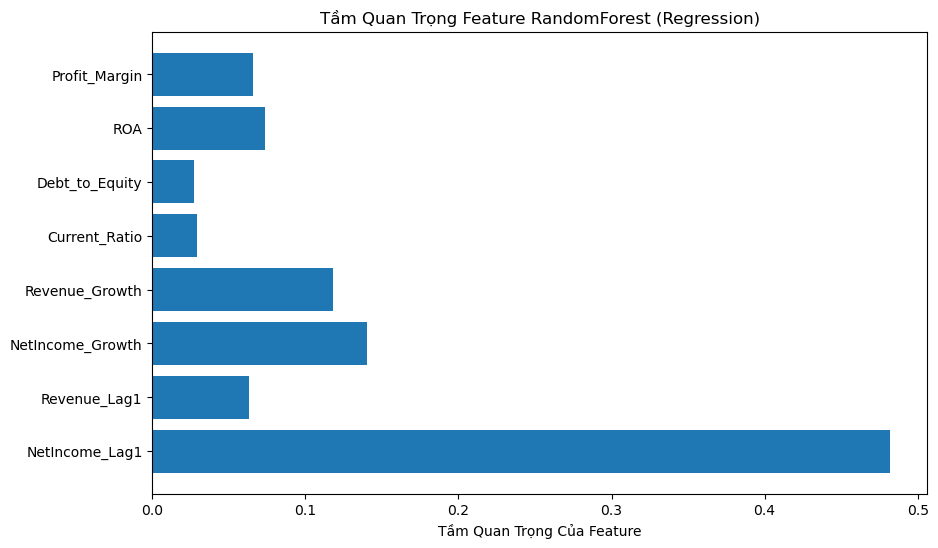

Top features cho Regression:
Profit_Margin: 0.0658
ROA: 0.0737
Revenue_Growth: 0.1179
NetIncome_Growth: 0.1405
NetIncome_Lag1: 0.4822


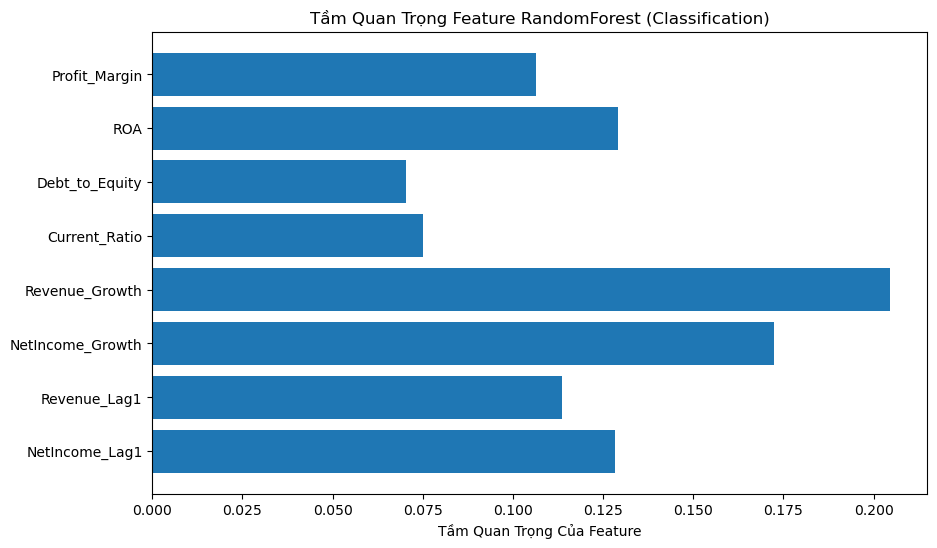

Top features cho Classification:
Revenue_Lag1: 0.1135
NetIncome_Lag1: 0.1284
ROA: 0.1292
NetIncome_Growth: 0.1724
Revenue_Growth: 0.2047


In [17]:
feature_importance_reg = model.feature_importances_
features_list = features

plt.figure(figsize=(10, 6))
plt.barh(features_list, feature_importance_reg)
plt.xlabel('Tầm Quan Trọng Của Feature')
plt.title('Tầm Quan Trọng Feature RandomForest (Regression)')
plt.show()

sorted_idx_reg = feature_importance_reg.argsort()
print("Top features cho Regression:")
for idx in sorted_idx_reg[-5:]:
    print(f"{features_list[idx]}: {feature_importance_reg[idx]:.4f}")

feature_importance_class = class_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(features_list, feature_importance_class)
plt.xlabel('Tầm Quan Trọng Của Feature')
plt.title('Tầm Quan Trọng Feature RandomForest (Classification)')
plt.show()

sorted_idx_class = feature_importance_class.argsort()
print("Top features cho Classification:")
for idx in sorted_idx_class[-5:]:
    print(f"{features_list[idx]}: {feature_importance_class[idx]:.4f}")